In [1]:
from __future__ import annotations

from importlib.metadata import version
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np

from modelbase.ode import Model, Simulator, mca
from modelbase.ode.utils.ratefunctions import mass_action_1, mass_action_2, reversible_mass_action_1_1, reversible_mass_action_2_1,reversible_mass_action_2_2

from scipy.integrate import solve_ivp

for pkg in ("modelbase",):
    print(f"{pkg:<10} {version(pkg)}")

Could not find cannot import name 'dopri5' from 'assimulo.lib' (c:\Users\retta001\AppData\Local\anaconda_new\envs\mb311\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'rodas' from 'assimulo.lib' (c:\Users\retta001\AppData\Local\anaconda_new\envs\mb311\Lib\site-packages\assimulo\lib\__init__.py)
Could not find cannot import name 'odassl' from 'assimulo.lib' (c:\Users\retta001\AppData\Local\anaconda_new\envs\mb311\Lib\site-packages\assimulo\lib\__init__.py)
Could not find ODEPACK functions.
Could not find RADAR5
Could not find GLIMDA.


modelbase  1.58.0


## Model parameters
| Symbol            | Value / Units                                                                | Description, Sources                                       |
| ----------------- | ---------------------------------------------------------------------------- | ------------------------------------------------- |
| `Chl`  | $50\times10^{-3},\frac{\mathrm{molChl}}{L}$                                                                          | Chlorophyll concentration, Shinkarev et al. 2002                        |
| `f_antennae_PSI`  | 0.45                                                                         | Fraction of light absorbed , Kroon et al 2006                       |
| `f_antennae_PSII` | 0.45                                                                         | Fraction of light absorbed , Kroon et al 2006                        |
| `Fd`        | $5 , \frac{\mathrm{mmol}}{\mathrm{molChl}}$                                                                         | concentration of Fd, Ebenhoh et al. 2014                          |
| `f_NPQ`           | 0.30                                                                         | Fraction of excitation lost to NPQ, assumed                |
| `kbet`            | $4.5\times10^{3},\mathrm{s^{-1}}$                                            | Back-electron transfer from P700 to PC(^o), Shinkarev et al. 2002        |
| `kb6f`            | $2.5,\frac{\mathrm{molChl}^2}{\mathrm{mmol}^2\cdot\mathrm{s}}$ | Reduction of PC by cyt b6f , Ebenhoh et al. 2014                        |
| `kcbc`            | $100,\mathrm{s^{-1}}$                                                        | Consumption of Fd(^r) by CBC cycle, assumed                |
| `kFd`             | $2.5\times10^{5},\frac{\mathrm{molChl}}{\mathrm{mmol\cdot s}}$               | Reduction of Fd by FB⁻·P700⁺·PC(^o), Ebenhoh et al. 2014               |
| `keqFd`           | 110 (-)                                                          | Fd equilibrium constant,Ebenhoh et al. 2014                           |
| `ket`             | $58\times10^{3},\mathrm{s^{-1}}$                                             | Electron transfer from PC(^r) in FB⁻·P700⁺·PC(^r), Shinkarev et al. 2002 |
| `Keqb6f`          | calculated                                                                   | Equilibrium constant for PC reduction by b6f , Ebenhoh et al. 2014      |
| `kI_+_off`        | $13\times10^{3},\mathrm{s^{-1}}$                                             | Release of PC(^r) from FB⁻·P700⁺, Drepper et al. 1996                  |
| `kI_+_on`         | $6\times10^{8},\frac{\mathrm{molChl}}{\mathrm{mmol\cdot s}}$                 | Binding of PC(^r) to FB⁻·P700⁺ , Drepper et al. 1996                  |
| `kI_off`          | $3.2\times10^{3},\mathrm{s^{-1}}$                                            | Release of PC(^r) from P700·FB·PC(^r) , Drepper et al. 1996            |
| `kI_on`           | $1.1\times10^{8},\frac{\mathrm{molChl}}{\mathrm{mmol\cdot s}}$               | Binding of PC(^r) to P700·FB , Drepper et al. 1996                    |
| `kII_off`         | $8\times10^{3},\mathrm{s^{-1}}$                                              | Release of PC(^o) from P700·FB·PC(^o) , Drepper et al. 1996           |
| `kII_on`          | $0.4\times10^{8},\frac{\mathrm{molChl}}{\mathrm{mmol\cdot s}}$               | Binding of PC(^o) to P700·FB , Drepper et al. 1996                 |
| `k_recomb`        | $2,\mathrm{s^{-1}}$                                                          | Charge recombination at PSI FB⁻ → P700⁺ , Shinkarev et al. 2002           |
| `NaI_PSI`         | 254, (-)                                                                          | Chl-a molecules per PSI , Kroon et al 2006                           |
| `NaI_PSII`        | 261, (-)                                                                          | Chl-a molecules per PSII , Kroon et al 2006                         |
| `NbI_PSI`         | 85, (-)                                                                           | Chl-b molecules per PSI , Kroon et al 2006                          |
| `NbI_PSII`        | 158, (-)                                                                          | Chl-b molecules per PSII , Kroon et al 2006                         |
| `PC`        | $4.0  , \frac{\mathrm{mmol}}{\mathrm{molChl}}$                                                                         | concentration of PC , Ebenhoh et al. 2014                          |
| `PQH2`        | $17.5  ,\frac{\mathrm{mmol}}{\mathrm{molChl}}$                                                                             | concentration of PSI , Ebenhoh et al. 2014                          |
| `PSII`        | $2.5 ,\frac{\mathrm{mmol}}{\mathrm{molChl}}$                                                                            | concentration of PSII , Ebenhoh et al. 2014                          |
| `PSII`        | $2.5  ,\frac{\mathrm{mmol}}{\mathrm{molChl}}$                                                                         | concentration of PSII , Ebenhoh et al. 2014                          |
| `rho_chl_a_PSI`   | $8.6749\times10^{-21},\frac{\mathrm{m^2}}{\mathrm{Chl,a}}$                   | Optical cross-section of Chl-a in PSI , Kroon et al 2006            |
| `rho_chl_a_PSII`  | $8.6749\times10^{-21},\frac{\mathrm{m^2}}{\mathrm{Chl,a}}$                   | Optical cross-section of Chl-a in PSII , Kroon et al 2006            |
| `rho_chl_b_PSI`   | $9.1222\times10^{-21},\frac{\mathrm{m^2}}{\mathrm{Chl,b}}$                   | Optical cross-section of Chl-b in PSI , Kroon et al 2006            |
| `rho_chl_b_PSII`  | $9.1222\times10^{-21},\frac{\mathrm{m^2}}{\mathrm{Chl,b}}$                   | Optical cross-section of Chl-b in PSII , Kroon et al 2006            |


### Binding of Plastocyanin (PC)


PSI is represented as a unit composed of P700 and FB as such excitation and charge separation are assumed one step.

The mechanism of binding of PSI and PC and rate constants were derived based on the work of Drepper et al. 1996 Doi: 10.1021/bi951471e.

The binding reactions are given by:

$FB_{(o,r)} \, P700_{(o,r)} + PC_{(o,r)} \; \rightleftharpoons \; FB_{(o,r)} \, P700_{(o,r)} \, PC_{(o,r)}$


**Rates:**

*Rate of binding of PC*

$V_{bind, FB_{(o,r)} P700_{(o,r)} PC_{(o,r)}} = k_{on}[FB_{(o,r)} P700_{(o,r)}][PC_{(o,r)}]$

*Rate of release of PC*

$V_{rel, FB_{(o,r)} \, P700_{(o,r)} \, PC_{(o,r)}} \; = \; k_{off} [FB_{(o,r)} \, P700_{(o,r)}  \, PC_{(o,r)}]$


**Legend:**
- *o* — oxidised  
- *r* — reduced  

**Notes:**
- P700 binds at a higher rate with **PCᵣ** than with **PCₒ**.  
- The **off-rate constants** are higher for **PCₒ** than for **PCᵣ**.  
- Oxidised **P700** binds **PC** with higher affinity than reduced **P700ᵣ**.  
- Oxidised **P700** binds with the **same affinity** to both **PCₒ** and **PCᵣ**, i.e., the off-rate constants are the same.


In [2]:
# Modelbase object
m=Model()

In [3]:
def get_binding_rate_constants(k:float,chl:float)->float:
    """
    Calculate binding rate constants on [Chl] basis.
    
    Parameters:
        k: Excitation rate co nstant for P700.FB (M^-1 s^-1)
        chl: Chlorophyll conc: M
    Returns:
        float: Binding rate constant, molChl/mmol/s
    """

    return  k*chl/1000

In [4]:
# FBo.P700r + PCr  < - > FBo.P700r.PCr, kI_on, kI_off

m.add_compounds(["PCr", "FBoP700r","FBoP700rPCr"])
m.add_parameters({"kI_off": 3.2e3,'Chl':50e-3,"kI_on_":1.1e8,"PSI_tot":2.5,"PC_tot":4})

m.add_derived_parameter(
    "kI_on",
    get_binding_rate_constants,
    parameters=["Chl","kI_on_"],
)

m.add_reaction_from_args(
    rate_name="V_bind_FBo.P700r.PCr",
    function=reversible_mass_action_2_1,
    stoichiometry={"FBoP700r": -1, "PCr": -1, "FBoP700rPCr": 1},
    args=["FBoP700r","PCr","FBoP700rPCr","kI_on", "kI_off"],
)

In [5]:
# FBo.P700r + PCo  < - > FBo.P700r.PCo, kII_on, kII_off

m.add_compounds(["PCo","FBoP700rPCo"])
m.add_parameters({"kII_off": 8e3,"kII_on_":0.4e8})

m.add_derived_parameter(
    "kII_on",
    get_binding_rate_constants,
    parameters=["Chl","kII_on_"],
)

m.add_reaction_from_args(
    rate_name="V_bind_FBo.P700r.PCo",
    function=reversible_mass_action_2_1,
    stoichiometry={"FBoP700r": -1, "PCo": -1, "FBoP700rPCo": 1},
    args=["FBoP700r","PCo","FBoP700rPCo","kII_on", "kII_off"],
) 

In [6]:
# FBr.P700o + PCr  < - > FBr.P700o.PCr, kI_+_on, kI_off

m.add_compounds(["FBrP700o","FBrP700oPCr"])
m.add_parameters({"kI_+_on_":6e8,"kI_+_off":13e3})

m.add_derived_parameter(
    "kI_+_on",
    get_binding_rate_constants,
    parameters=["Chl","kI_+_on_"],
)
m.add_reaction_from_args(
    rate_name="V_bind_FBr.P700o.PCr",
    function=reversible_mass_action_2_1,
    stoichiometry={"FBrP700o": -1, "PCr": -1, "FBrP700oPCr": 1},
    args=["FBrP700o","PCr","FBrP700oPCr","kI_+_on", "kI_+_off"],
) 



In [7]:
# FBr.P700o + PCo  < - > FBr.P700o.PCo, kI_+_on, kI_off
m.add_compounds(["FBrP700oPCo"])
m.add_reaction_from_args(
    rate_name="V_bind_FBr.P700o.PCo",
    function=reversible_mass_action_2_1,
    stoichiometry={"FBrP700o": -1, "PCo": -1, "FBrP700oPCo": 1},
    args=["FBrP700o","PCo","FBrP700oPCo","kI_+_on", "kI_+_off"],
) 

In [8]:
# FBo.P700o + PCr  < - > FBo.P700o.PCr, kI_+_on, kI_off
m.add_compounds(["FBoP700o","FBoP700oPCr"])
m.add_reaction_from_args(
    rate_name="V_bind_FBo.P700o.PCr",
    function=reversible_mass_action_2_1,
    stoichiometry={"FBoP700o": -1, "PCr": -1, "FBoP700oPCr": 1},
    args=["FBoP700o","PCr","FBoP700oPCr","kI_+_on", "kI_+_off"],
) 


In [ ]:
# FBo.P700o + PCo  < - > FBo.P700o.PCo, kI_+_on, kI_off
m.add_compounds(["FBoP700oPCo"])

m.add_reaction_from_args(
    rate_name="V_bind_FBo.P700o.PCo",
    function=mass_action_2,
    stoichiometry={"FBoP700o": -1, "PCo": -1, "FBoP700oPCo": 1},
    args=["FBoP700o","PCo","kI_+_on"],
)

m.add_reaction_from_args(
    rate_name="V_rel_FBo.P700o.PCo",
    function=mass_action_1,
    stoichiometry={"FBoP700o": 1, "PCo": 1, "FBoP700oPCo": -1},
    args=["FBoP700oPCo", "kI_+_off"],
)

In [10]:
# FBr.P700r + PCr  < - > FBr.P700r.PCr, kI_on, kI_off
m.add_compounds(["FBrP700r","FBrP700rPCr"])

m.add_reaction_from_args(
    rate_name="V_bind_FBr.P700r.PCr",
    function=reversible_mass_action_2_1,
    stoichiometry={"FBrP700r": -1, "PCr": -1, "FBrP700rPCr": 1},
    args=["FBrP700r","PCr","FBrP700rPCr","kI_on", "kI_off"],
)

In [11]:
# FBr.P700r + PCo  < - > FBr.P700r.PCo, kI_on, kI_off
m.add_compounds(["FBrP700rPCo"])

m.add_reaction_from_args(
    rate_name="V_bind_FBr.P700r.PCo",
    function=mass_action_2,
    stoichiometry={"FBrP700r": -1, "PCo": -1, "FBrP700rPCo": 1},
    args=["FBrP700r","PCo","kII_on"],
)

# FBr.P700r + PCo  < - > FBr.P700r.PCo, kI_on, kI_off
m.add_compounds(["FBrP700rPCo"])

m.add_reaction_from_args(
    rate_name="V_rel_FBr.P700r.PCo",
    function=mass_action_1,
    stoichiometry={"FBrP700r": 1, "PCo": 1, "FBrP700rPCo": -1},
    args=["FBrP700rPCo", "kII_off"],
)

### Excitation and charge separation

The excitation and charge separation are treated as one step and assumed to be limited by excitation. The reactions is represented as:


$FB_{(o)} \, P700_{(r)} + hv \; \rightleftharpoons \; FB_{(r)} \, P700_{(o)} $

PC-bound chemical species are excited as:

$FB_{(o)} \, P700_{(r)} \, PC_{(o,r)}+ hv \; \rightleftharpoons \; FB_{(r)} \, P700_{(o)} \, PC_{(o,r)}$

**Excitation:**

Rate constants of excitation of PSI and PSII are based on, Kroon et al 2006. Optical cross sectional area of PSI and PSII are calculated using number of chl a and chlb molecules per photosystem and thier optical cross section. The incident light was partitioned to PSI and PSII. For PSII, the fraction of excitation dessipated by NPQ was accounted for.


**Legend:**
- *o* — oxidised  
- *r* — reduced  

**Notes:**
- The forward rate constant is a function of light intensity.  

* Rate constants of excitation of PSI and PSII are based on, Kroon et al 2006


In [12]:
def excitation_PS(PFD:float,Na:float,Nb:float,phi,f_antennae:float,f_NPQ:float=0.0)->float:
    """
    Returns rate constant for excitation of PSI or PSII, excitation events per ms.
    Based on Kroon et al 2006

    Parameters:
        PFD : Irradiance,umol m-2 s-1
        Na  : Number of chla molecules per photosystem
        Nb  : Number of chlb molecules per photosystem
        phi : Quantum efficiency of photosystem
        f_antennae  : fraction of light absorbed by antennae
        f_NPQ  : fraction of excitation lost due to NPQ

    Returns:
        float: rate constant, excitation events per s.
    """
    # # # Excitation of PSI, Kroon et al 2006
    rho_chl_a = 8.6749e-21   # m2/chla, optical cross section of chl a
    rho_chl_b = 9.1222e-21   # m2/chlb, optical cross section of chl b

    av_No = 6.022e23         # molecules/mol (Avogadro’s number)

    cfI= av_No*1e-6          # micro mol/s to quanta/s 
    
    rho_PSI = rho_chl_a*Na + rho_chl_b*Nb  # m2, optical cross section of PSI
    exc_I = rho_PSI*PFD*cfI                 # quanta/s, rate of excitation of PSI
    
    k_exc = exc_I * phi*f_antennae*(1-f_NPQ) # excitations/s, 
    
    return k_exc




In [13]:
# FBo.P700r + hv < - > FBr.P700o

m.add_parameters({'Light_intensity':10,'k_recomb':1/0.5,"Na_PSI":254,"Nb_PSI":85,"phi_PSI":0.97,"f_antennae":0.45})
m.add_derived_parameter(
    "k_exc",
    excitation_PS,
    parameters=["Light_intensity","Na_PSI","Nb_PSI","phi_PSI","f_antennae"], #excitation_PS(PFD,Na,Nb,phi,f_antennae,f_NPQ=None)
)
m.add_reaction_from_args(
    rate_name="V_ex_FBo.P700r",
    function=reversible_mass_action_1_1,
    stoichiometry={"FBoP700r": -1, "FBrP700o": 1},
    args=["FBoP700r","FBrP700o","k_exc", "k_recomb"],
)


In [14]:
# FBo.P700r.PCr + hv < - > FBr.P700o.PCr

m.add_reaction_from_args(
    rate_name="V_ex_FBo.P700r.PCr",
    function=reversible_mass_action_1_1,
    stoichiometry={"FBoP700rPCr": -1, "FBrP700oPCr": 1},
    args=["FBoP700rPCr","FBrP700oPCr","k_exc", "k_recomb"],
)


In [15]:
# FBo.P700r.PCo + hv < - > FBr.P700o.PCo

m.add_reaction_from_args(
    rate_name="V_ex_FBo.P700r.PCo",
    function=reversible_mass_action_1_1,
    stoichiometry={"FBoP700rPCo": -1, "FBrP700oPCo": 1},
    args=["FBoP700rPCo","FBrP700oPCo","k_exc", "k_recomb"],
)

### Reduction of oxidised Ferredoxin

The reduction of ferredoxin occurs after charge separation by PC bound or unbound species 
The reactions can be represented as:
$$
FB_{(r)} \, P700_{(o)} + FD_{(o)} \; \rightleftharpoons \; FB_{(o)} \, P700_{(o)} +FD_{(r)}
$$

PC-bound chemical species reduced ferredoxin as:
$$
FB_{(r)} \, P700_{(o)} \, PC_{(o,r)} + FD_{(o)} \; \rightleftharpoons \; FB_{(o)} \, P700_{(o,r)} \, PC_{(o,r)} + FD_{(r)}
$$

**Legend:**
- *o* — oxidised  
- *r* — reduced  




In [16]:
# # FBr.P700o + Fdo < - > FBo.P700o + Fdr


def Keq_FAFd(E0_FA, F, E0_Fd, RT):
    DG1 = -E0_FA * F
    DG2 = -E0_Fd * F
    DG = -DG1 + DG2
    K = np.exp(-DG / RT)
    return K


def ratio(kfd,keq):
    return kfd/keq

def proportional(R,T):
    return R*T


m.add_compounds(["FDo","FDr"])
m.add_parameters({"E0_FA": -0.550,"E0_Fd": -0.430,"F": 96.485,"R": 8.3e-3,"T": 298.0,"kFd": 2.5e5,"Fd_tot":5})

m.add_derived_parameter(
    "RT",
    proportional,
    parameters=["R","T"],
)

m.add_derived_parameter(
    "keqFd",
    Keq_FAFd,
    parameters=["E0_FA","F","E0_Fd","RT"],
)

m.add_derived_parameter(
    "kbwd",
    ratio,
    parameters=["kFd","keqFd"],
)

m.add_reaction_from_args(
    rate_name="V_FD_red_P700o",
    function=reversible_mass_action_2_2,
    stoichiometry={"FBrP700o": -1, "FDo": -1, "FBoP700o": 1, "FDr": 1},
    args=["FBrP700o","FDo","FBoP700o","FDr","kFd", "kbwd"],
)
    

In [17]:
#  FBr.P700o.PCr + Fdo < - > FBo.P700o.PCr + Fdr
m.add_reaction_from_args(
    rate_name="V_FD_red_P700o.PCr",
    function=reversible_mass_action_2_2,
    stoichiometry={"FBrP700oPCr": -1, "FDo": -1, "FBoP700oPCr": 1, "FDr": 1},
    args=["FBrP700oPCr","FDo","FBoP700oPCr","FDr","kFd", "kbwd"],
)
    

In [18]:
#  FBr.P700o.PCo + Fdo < - > FBo.P700o.PCo + Fdr
m.add_reaction_from_args(
    rate_name="V_FD_red_P700o.PCo",
    function=reversible_mass_action_2_2,
    stoichiometry={"FBrP700oPCo": -1, "FDo": -1, "FBoP700oPCo": 1, "FDr": 1},
    args=["FBrP700oPCo","FDo","FBoP700oPCo","FDr","kFd", "kbwd"],
)

In [19]:
#  FBr.P700r.PCo + Fdo < - > FBo.P700r.PCo + Fdr
m.add_reaction_from_args(
    rate_name="V_FD_red_P700r.PCo",
    function=reversible_mass_action_2_2,
    stoichiometry={"FBrP700rPCo": -1, "FDo": -1, "FBoP700rPCo": 1, "FDr": 1},
    args=["FBrP700rPCo","FDo","FBoP700rPCo","FDr","kFd", "kbwd"],
)

In [20]:
#  FBr.P700r.PCr + Fdo < - > FBo.P700r.PCr + Fdr
m.add_reaction_from_args(
    rate_name="V_FD_red_P700r.PCr",
    function=reversible_mass_action_2_2,
    stoichiometry={"FBrP700rPCr": -1, "FDo": -1, "FBoP700rPCr": 1, "FDr": 1},
    args=["FBrP700rPCr","FDo","FBoP700rPCr","FDr","kFd", "kbwd"],
)

In [21]:
#  FBr.P700r + Fdo < - > FBo.P700r + Fdr
m.add_reaction_from_args(
    rate_name="V_FD_red_P700r",
    function=reversible_mass_action_2_2,
    stoichiometry={"FBrP700r": -1, "FDo": -1, "FBoP700r": 1, "FDr": 1},
    args=["FBrP700r","FDo","FBoP700r","FDr","kFd", "kbwd"],
)

### Electron transport from PCr to P700o

Electron from PCr can transfer to oxidised P700 before or after FD reduction 

The reactions can be represented as:

$$
FB_{(o,r)} \, P700_{(o)} \, PC_{(r)} \; \rightleftharpoons \; FB_{(o,r)} \, P700_{(r)} \, PC_{(o)} 
$$

**Legend:**
- *o* — oxidised  
- *r* — reduced  




In [22]:
#  FBr.P700o.PCr < - > FBr.P700r.PCo
# m.add_compounds(["FBrP700oPCr","FBrP700rPCo"])
m.add_parameters({"ket": 58e3,'kbet':4.5e3})

m.add_reaction_from_args(
    rate_name="V_et_FBr.P700o.PCr",
    function=reversible_mass_action_1_1,
    stoichiometry={"FBrP700oPCr": -1, "FBrP700rPCo": 1},
    args=["FBrP700oPCr","FBrP700rPCo","ket", "kbet"],
)

In [23]:
#  FBo.P700o.PCr < - > FBo.P700r.PCo
# m.add_compounds(["FBrP700oPCr","FBrP700rPCo"])

m.add_reaction_from_args(
    rate_name="V_et_FBo.P700o.PCr",
    function=reversible_mass_action_1_1,
    stoichiometry={"FBoP700oPCr": -1, "FBoP700rPCo": 1},
    args=["FBoP700oPCr","FBoP700rPCo","ket", "kbet"],
)

### Cytochrome b6f reactions

Electron from PCr can transfer to oxidised P700 before or after FD reduction 

The reactions can be represented as:

$$
PQH_{2}  + 2 PC_{o}  \; \rightleftharpoons \; PQ + 2PC_{r} 
$$

**Legend:**
- *o* — oxidised  
- *r* — reduced  




In [24]:
def vB6f(PCo, PCr, PQ, PQtot, k_b6f, Keq_b6f):    
    k_b6f_reverse = k_b6f / Keq_b6f
    f_PQ=PQ/PQtot #want to keep the rates in terms of fraction of PQHs, not total number
    f_PQH2=1-f_PQ
    return f_PQH2*PCo**2*k_b6f - f_PQ*PCr**2*k_b6f_reverse 


def keq_PQred(E0_QA, F, E0_PQ, pHstroma, dG_pH, RT):
    DG1 = -E0_QA * F
    DG2 = -2 * E0_PQ * F
    DG = -2 * DG1 + DG2 + 2 * pHstroma * dG_pH
    K = np.exp(-DG / RT)
    return K

def dg_ph(r, t):
    return np.log(10) * r * t


m.add_parameters({"E0_QA": -0.140,"E0_PQ": 0.354,"kb6f": 2.5,'PQtot':17.5,"pHstroma":7.9})


m.add_derived_parameter(
    parameter_name="dG_pH",
    function=dg_ph,
    parameters=["R", "T"],
)

m.add_derived_parameter(
    "Keqb6f",
    keq_PQred,
    parameters=["E0_QA","F","E0_PQ","pHstroma","dG_pH","RT"],
)

m.add_compounds(["PQH2","PQ"])
m.add_reaction_from_args(
    rate_name="vB6f",
    function=vB6f,
    stoichiometry={"PQH2": -1,"PCo": -2, "PQ": 1,"PCr": 2},
    args=["PCo","PCr","PQ","PQtot","kb6f", "Keqb6f"],
)

### PSII reactions

PSII  activation by light and charge separation are considered as one step limited by excitation of PSII. 
The fraction of excitatation lost by NPQ is accounted for.

The reactions can be represented as:

$$
PQ + PSII  \; \rightleftharpoons \; PQH_{2}  
$$




In [25]:
# excitation and charge separation
m.add_parameters({"Na_PSII":261,"Nb_PSII":158,"f_NPQ":0.30,"PSII":2.5})
m.add_derived_parameter(
    "k2_exc",
    excitation_PS,
    parameters=["Light_intensity","Na_PSII","Nb_PSII","phi_PSI","f_antennae","f_NPQ"], #excitation_PS(PFD,Na,Nb,phi,f_antennae,f_NPQ=None)
)

In [26]:
def vPSII(PQ, PQtot, k2_exc,PSII):    
    f_PQ=PQ/PQtot
    return k2_exc*f_PQ*PSII

m.add_reaction_from_args(
    rate_name="VPSII",
    function=vPSII,
    stoichiometry={"PQ": -1,"PQH2": 1},
    args=["PQ","PQtot","k2_exc","PSII"],
)

### CBC cycle model

CBC cycle is assumed to consume FDr and produce product P

The reactions can be represented as:

$$
FD_{r}   \; \rightleftharpoons \; P + FD_{o} 
$$

**Legend:**
- *o* — oxidised  
- *r* — reduced  




In [27]:
m.add_parameters({"kcbc": 0.1e3})
m.add_compounds(["P"])

m.add_reaction_from_args(
    rate_name="VCBC",
    function=mass_action_1,
    stoichiometry={"FDr": -1,"FDo": 1,"P": 1},
    args=["FDr","kcbc"],
)

In [28]:
# dark adapted state
y0 = {
        "FBoP700r": 2.5,  # mmol/molChl,FB.P70r concentration, e photosynthesis
        "FBoP700rPCr": 0.0,    # mmol/molChl,FB.P700.PCred concentration (PCred-bound state)
        "FBoP700rPCo": 0.0,    # mmol/molChl,FB.P700.PCox concentration (PCox-bound state)
        "FBrP700o": 0.0,    # mmol/molChl,FB-.P700+.PCox concentration (excited PCox-bound state)
        "FBrP700oPCr": 0.0,    # mmol/molChl,FB-.P700+ concentration (excited unbound state)
        "FBrP700oPCo": 0.0,    # mmol/molChl,FB-.P700+.PCred concentration (excited PCred-bound state)
        "FBoP700o": 0.0,    # mmol/molChl,FB-.P700.PCOx concentration (reduced unbound state)
        "FBoP700oPCr": 0.0,    # mmol/molChl,FFB.P700+.PCox concentration (oxidised P700 PCox-bound state)
        "FBoP700oPCo": 0.0,    # mmol/molChl,FB.P700+ concentration (oxidised P700)
        "FBrP700rPCo":0.0,    # mmol/molChl,FB.P700+.PCred concentration (oxidized PCred-bound state)
        "PCo": 4,   # mmol/molChl, PCox concentration (oxidized plastocyanin), e photosynthesis
        "PCr": 0.0,     # mmol/molChl, PCred concentration (reduced plastocyanin)
        "FDo": 5.0,     # mmol/molChl, Fd concentration (oxidised ferredoxin)
        "FDr": 0.0,    # mmol/molChl, Fd- concentration (reduced ferredoxin)
        "PQ": 17.5,    # mmol/molChl, PQ concentration (oxidised plastoquinon)
        "PQH2": 0.0,    # mmol/molChl, PQH2 concentration (reduced plastoquinon)
        "P": 0.0,     # mmol/molChl, product from Fd- consumption in CBC cycle
        "FBrP700r": 0.0,    # mmol/molChl, FBr.P700r concentration (excited PCox-bound state)
        "FBrP700rPCr": 0.0,     # mmol/molChl, FBr.P700.PCr concentration (excited unbound state)
    }

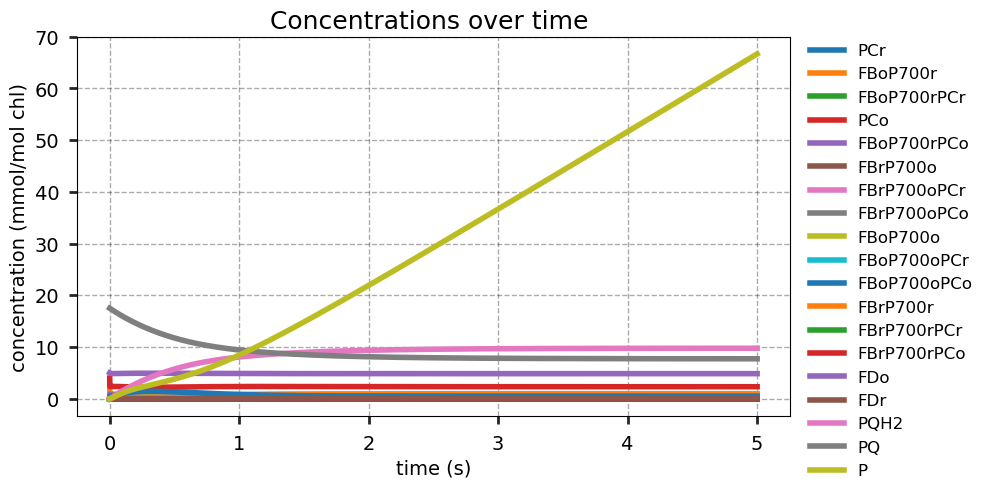

In [29]:
pfd = 10
m.update_parameter("Light_intensity",pfd)

fig, ax = (
    Simulator(m)
    .initialise(y0)
    .simulate_and(t_end=5)
    .plot(
        xlabel="time (s)",
        ylabel="concentration (mmol/mol chl)",
        title="Concentrations over time ",
        figure_kwargs={"figsize": (10, 5)},
    )
)
plt.show()

In [30]:
dicts = {
        'fb_p700_indices' : ["FBoP700r","FBoP700rPCr","FBoP700rPCo","FBrP700o","FBrP700oPCr","FBrP700oPCo","FBrP700r","FBrP700rPCr","FBoP700o"
                            ,"FBoP700oPCr","FBoP700oPCo"],  # rows contributing to FB·P700
        'fd_cbc_indices' : ["FDr", "FDo"],                     # Fdo, Fdr, CBC
        'pq_indices' : ["PQ", "PQH2"],                            # PQ and PQH2
        'pc_indices' : ["PCr","PCo","FBoP700rPCr","FBoP700rPCo","FBrP700oPCr","FBrP700oPCo",
                        "FBoP700oPCo","FBoP700oPCr","FBrP700rPCr","FBrP700rPCo"]             # PCox and PCred
    }

cols = [item for sublist in dicts.values() for item in sublist]

# Separate lists
cols_red = [x for x in cols if ("P700r" in x) or (x in ["FDr", "PCr", "PQH2"])]
cols_ox  = [x for x in cols if ("P700o" in x) or (x in ["PCo", "PQ", "FDo"])]

print("Reduced:", cols_red)
print("Oxidized:", cols_ox)





Reduced: ['FBoP700r', 'FBoP700rPCr', 'FBoP700rPCo', 'FBrP700r', 'FBrP700rPCr', 'FDr', 'PQH2', 'PCr', 'FBoP700rPCr', 'FBoP700rPCo', 'FBrP700rPCr', 'FBrP700rPCo']
Oxidized: ['FBrP700o', 'FBrP700oPCr', 'FBrP700oPCo', 'FBoP700o', 'FBoP700oPCr', 'FBoP700oPCo', 'FDo', 'PQ', 'PCo', 'FBrP700oPCr', 'FBrP700oPCo', 'FBoP700oPCo', 'FBoP700oPCr']


In [31]:
def state_v_indices():
    # Define species indices for each group

    dict = {
        'fb_p700_indices' : ["FBoP700r","FBoP700rPCr","FBoP700rPCo","FBrP700o","FBrP700oPCr","FBrP700oPCo","FBrP700r","FBrP700rPCr","FBoP700o"
                            ,"FBoP700oPCr","FBoP700oPCo"],  # rows contributing to FB·P700
        'fd_cbc_indices' : ["FDr", "FDo"],                     # Fdo, Fdr, CBC
        'pq_indices' : ["PQ", "PQH2"],                            # PQ and PQH2
        'pc_indices' : ["PCr","PCo","FBoP700rPCr","FBoP700rPCo","FBrP700oPCr","FBrP700oPCo",
                        "FBoP700oPCo","FBoP700oPCr","FBrP700rPCr","FBrP700rPCo"]             # PCox and PCred
    }

    return dict

def calculate_total_mass(df):
    """
    Calculate the total mass of species to check for conservation
    """
    dict_indices = state_v_indices()
    
    fb_p700_indices = dict_indices['fb_p700_indices']
    pq_indices = dict_indices['pq_indices']
    pc_indices = dict_indices['pc_indices']
    fd_cbc_indices = dict_indices['fd_cbc_indices']

    fb_p700_sum = df[fb_p700_indices].sum(axis=1)
    pq_sum = df[pq_indices].sum(axis=1)
    pc_sum = df[pc_indices].sum(axis=1)  
    fd_sum = df[fd_cbc_indices].sum(axis=1)

    return fb_p700_sum,pq_sum,pc_sum,fd_sum

def compute_electrons(df):
    """
    Returns the fraction of P700+
    
    Parameters:
        sol.y (array): concentration of species
    
    Returns:
        array: fraction of P700+.
    """
    dict_indices = state_v_indices()
    cols = [item for sublist in dict_indices.values() for item in sublist]

    cols_red = [x for x in cols if ("P700r" in x) or (x in ["FDr", "PCr", "PQH2"])]
    cols_oxd  = [x for x in cols if ("P700o" in x) or (x in ["PCo", "PQ", "FDo"])]

    red = df[cols_red].sum(axis=1)
    ox = df[cols_oxd].sum(axis=1) 

    return ox,red

# Define custom labels for species
custom_labels = {
    "FBoP700r": r"$FB{^o}.P700{^r}$",    # FB.P700 concentration
    "FBoP700rPCr": r"$FB{^o}.P700{^r}.PC{^r}$",  # FB.P700.PCred concentration (PCred-bound state)
    "FBoP700rPCo": r"$FB{^o}.P700{^r}.PC{^o}$",  # FB.P700.PCox concentration (PCox-bound state)
    "FBrP700oPCr": r"$FB{^r}.P700{^o}.PC{^r}$",  # FB-.P700+.PCox concentration (excited PCox-bound state)
    "FBrP700o": r"$FB{^r}.P700{^o}$",  # FB-.P700+ concentration (excited unbound state)
    "FBrP700oPCo": r"$FB{^r}.P700{^o}.PC{^o}$",  # FB-.P700+.PCred concentration (excited PCred-bound state)
    "FBoP700oPCo": r"$FB{^o}.P700{^o}.PC{^o}$",  # FB-.P700 concentration (reduced unbound state)
    "FBoP700oPCr": r"$FB{^o}.P700{^o}.PC{^r}$",  # FFB.P700+.PCox concentration (oxidised P700 PCox-bound state)
    "FBoP700o": r"$FB{^o}.P700{^o}$",  # FB.P700+ concentration (oxidised P700)
    "FBrP700rPCo": r"$FB{^r}.P700{^r}.PC{^o}$", # FB.P700+.PCred concentration (oxidized PCred-bound state)
    "PCo": r"$PC{^o}$", # PCox concentration (oxidized plastocyanin)
    "PCr": r"$PC{^r}$", # PCred concentration (reduced plastocyanin)
    "FDo": r"$FD{^o}$", # Fdo concentration (oxidised ferredoxin)
    "FDr": r"$FD{^r}$", # Fdr concentration (reduced ferredoxin)
    "PQ": r"$PQ{^o}$",  # PQ+
    "PQH2": r"$PQH_{2}$",  # PQH2
    "P": "CBC",  # product from Fd- consumption in CBC cycle
    "FBrP700r": r"$FB{^r}.P700{^r}$",  # FBr.P700r
    "FBrP700rPCr": r"$FB{^r}.P700{^r}.PC{^r}$"  # FBr.P700r.PCr

}

species_colors = {
    'FBoP700r': '#1f77b4',  # blue
    'FBoP700rPCr': '#ff7f0e',  # orange
    'FBoP700rPCo': '#2ca02c',  # green
    'FBrP700o': '#d62728',  # red
    'FBrP700oPCr': '#9467bd',  # purple
    'FBrP700oPCo': '#8c564b',  # brown
    'FBoP700o': '#e377c2',  # pink
    'FBoP700oPCr': '#7f7f7f',  # gray
    'FBoP700oPCo': '#bcbd22',  # lime
    'FBrP700rPCo': '#17becf', # cyan
    'PCo': '#1a55FF', # vibrant blue
    'PCr': '#F28500', # tangerine
    'FDo': '#00B945', # jade green
    'FDr': '#DC267F', # magenta
    'PQ': '#FF6DB6', # hot pink
    'PQH2': '#785EF0', # indigo
    'P': '#FE6100', # orange-red
    'FBrP700r': '#FFB000', # golden yellow
    'FBrP700rPCr': '#648FFF', # sky blue
}

species_groups = [

    ["FBoP700r","FBoP700rPCr", "FBoP700rPCo"],         # P700 binding and excitation
    ["FBrP700o", "FBrP700oPCr", "FBrP700oPCo"],         # FB-.P700+ bounded or free and FB-.P700
    ["FBoP700o",                     # FB-.P700.PCox bounded or free
    "FBoP700oPCr","FBoP700oPCo"],      # FB.P700+ bounded or free, after e transfer to Fd
    ["PCo", "PCr"],             # PCox, PCred
    ["FDo","FDr"],              # Fd and Fd-
    ["PQ","PQH2"],              # PQ+, PQH2
    ["P"],                    # product from Fd- consumption in CBC cycle
    ["FBrP700r", "FBrP700rPCr", "FBrP700rPCo"]              # FBr.P700r bounded or free and FBr.P700r.PCr
    
]

def plot_conservation(df):

    """
    Plots the conservation of mass.
    
    Parameters:
        sol (tuple): Solution of ODE.
    """
    fb_p700_sum,pq_sum,pc_sum,fd_cbc_indices = calculate_total_mass(df)
   
    # Plot each balance over time
    plt.figure()

    plt.plot(pq_sum, label='PQ + PQH2', marker='^')
    plt.axhline(17.5, color='gray', linestyle='--', label='Expected total  = 17.5')
  
    plt.plot(fd_cbc_indices, label='Fdo + Fdr', marker='^')
    plt.axhline(5, color='gray', linestyle='--', label='Expected total  = 5')

    plt.plot(pc_sum, label='Pco + PCr', marker='^')
    plt.axhline(4, color='gray', linestyle='--', label='Expected total = 4')

    plt.plot(fb_p700_sum, label='FB·P700 Total', marker='o')
    plt.axhline(2.5, color='gray', linestyle='--', label='Expected total  = 2.5')
    
    plt.title("Species pool balance over time")
    plt.xlabel("Time Step")
    plt.ylabel("Total Concentration")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_conc_electrons(df):
    plt.figure()
    ox,red = compute_electrons(df)
    plt.plot(ox,label='ox')
    plt.plot(red,label='red')
    plt.plot(red+ox,label='total')
    plt.title("Balance of electrons")
    plt.xlabel("Time Step (ms)")
    plt.ylabel("Total Concentration (mol/molChl)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_single_solution(df: Any, species_groups: List[List[str]]) -> None:
    """
    Helper function to plot species concentrations from a single solution object.
    
    Parameters:
        solution (Any): Solution object from scipy.integrate.solve_ivp
        species_groups (List[List[str]]): List of groups, where each group is a list of species names
    """
    for group in species_groups:
        plt.figure(figsize=(8, 5))
        
        # Calculate base index for this group
        base_index = sum(len(g) for g in species_groups[:species_groups.index(group)])
        
        # Plot each species in the group
        for i, species in enumerate(group):
            species_index = base_index + i
            color = species_colors.get(species, None)
            
            plt.plot(
                df[species], 
                label=custom_labels.get(species, species),
                color=color
            )
        
        # Set labels and show plot
        plt.xlabel("Time (ms)")
        plt.ylabel("Concentration (mmol/mol Chl)")
        plt.legend(loc="best")
        plt.show()

In [32]:
result = (
    Simulator(m)
    .initialise(y0)
    .simulate_and(t_end=5)
)
df = result.get_results_df()

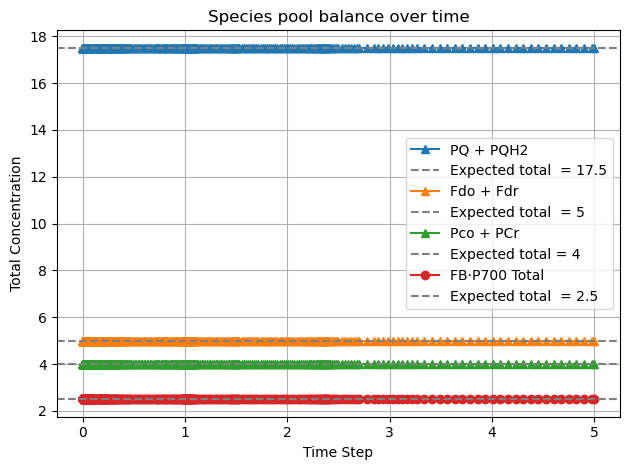

In [33]:
%matplotlib inline
plot_conservation(df)


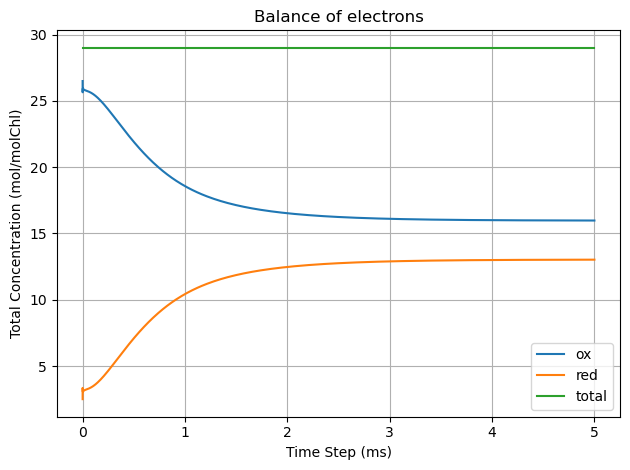

In [34]:
plot_conc_electrons(df)

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


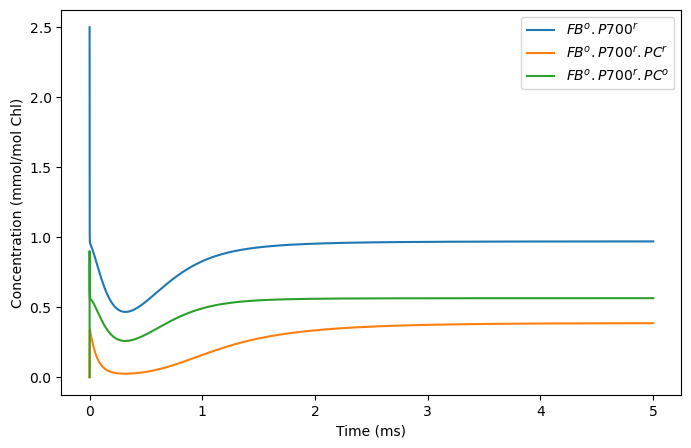

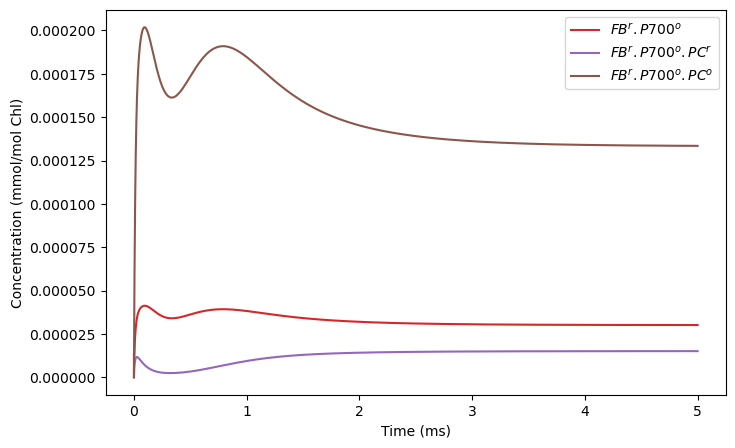

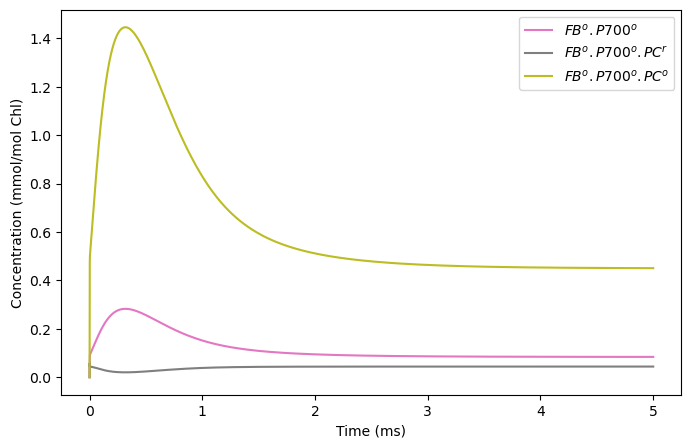

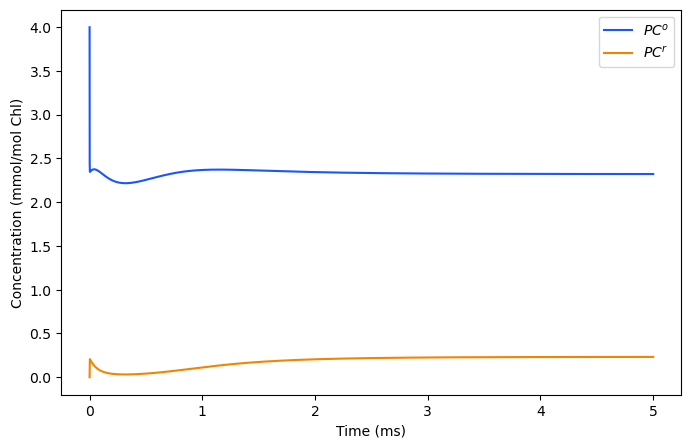

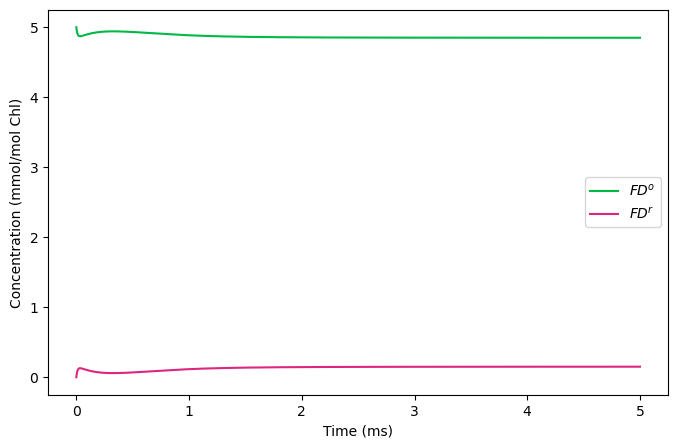

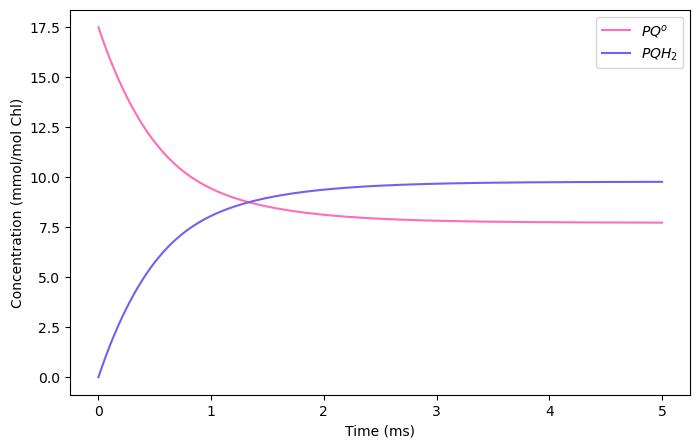

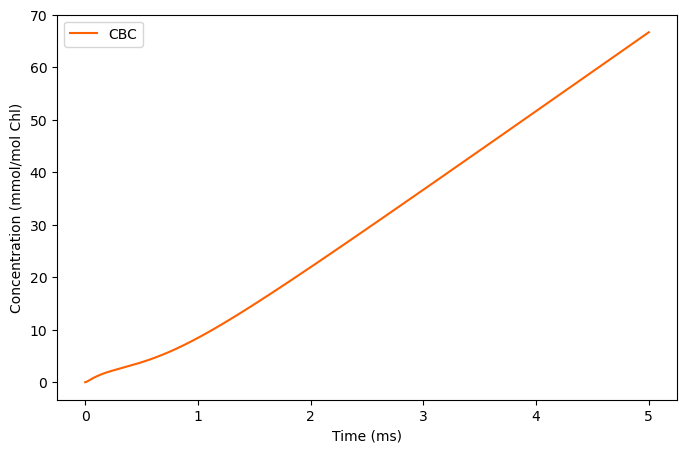

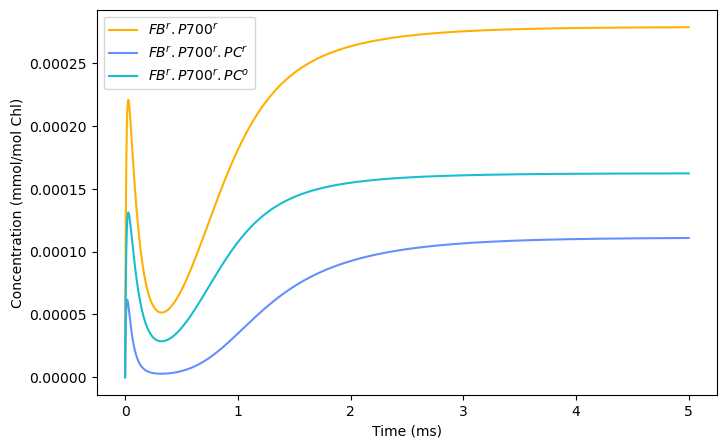

In [35]:
plot_single_solution(df,species_groups)

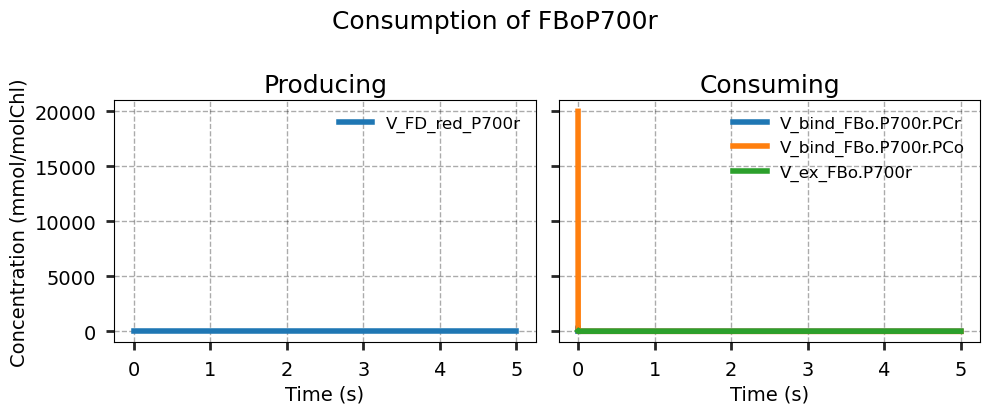

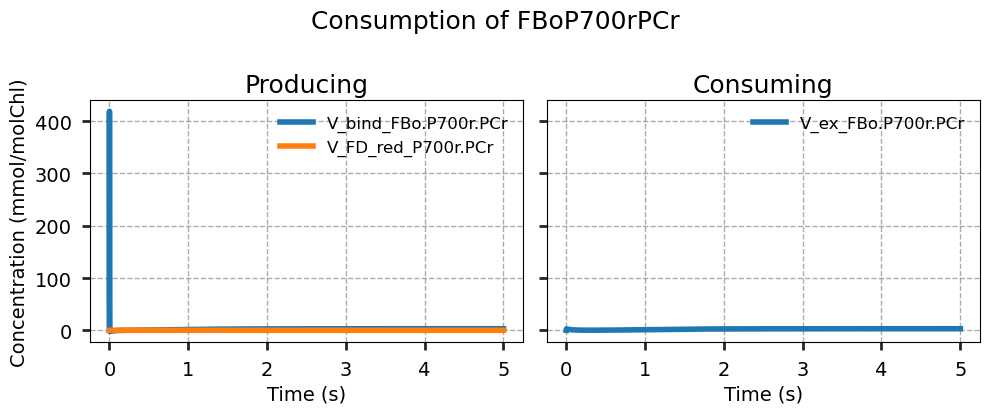

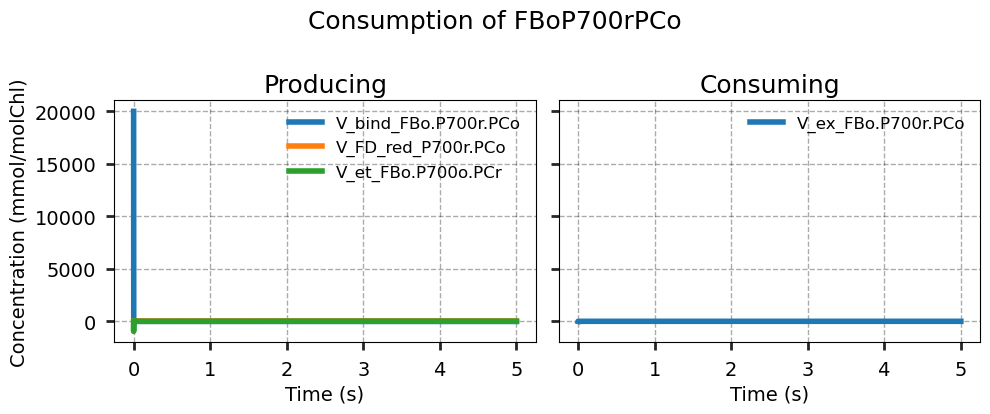

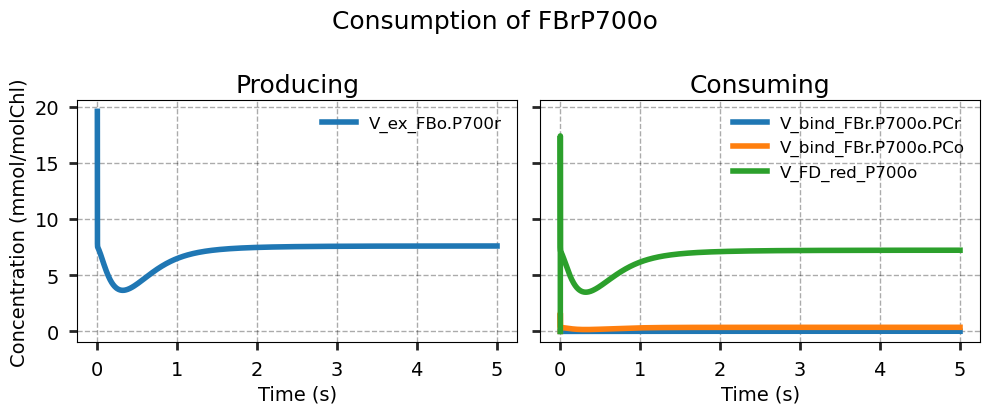

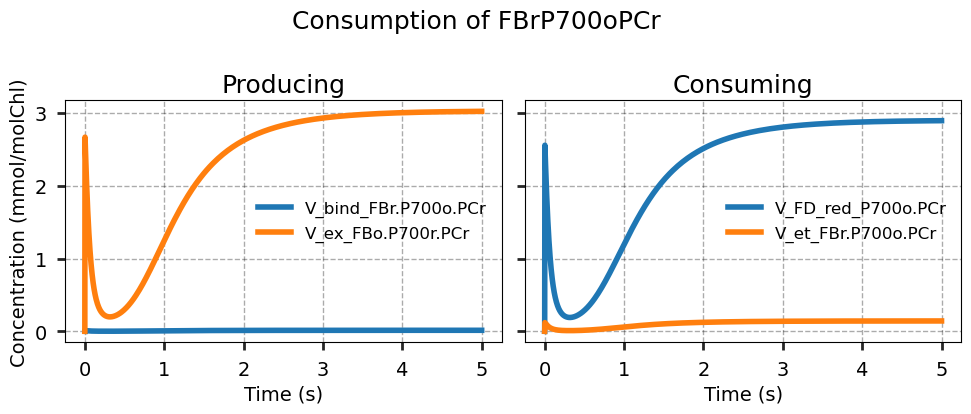

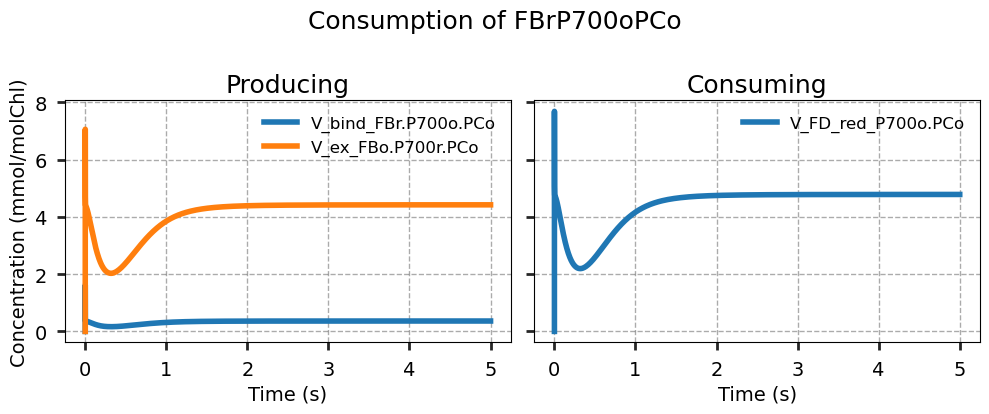

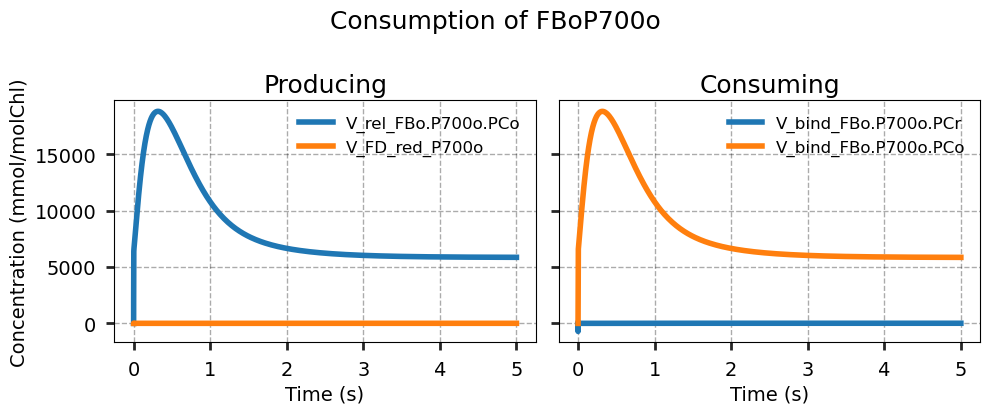

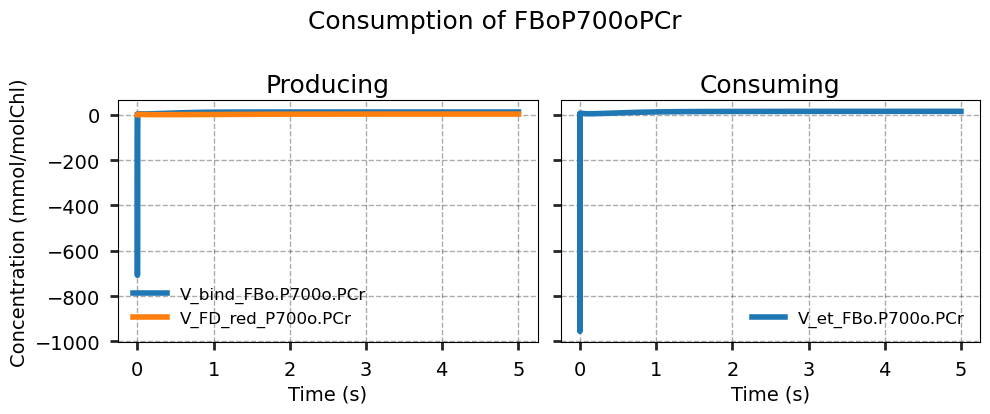

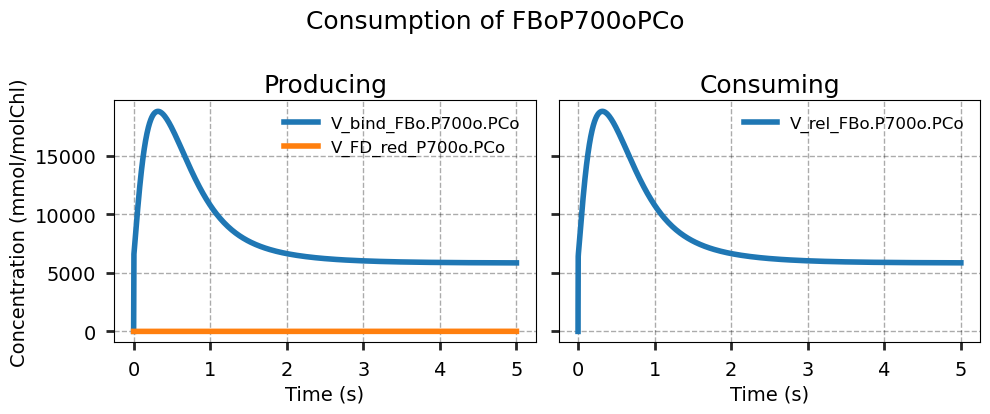

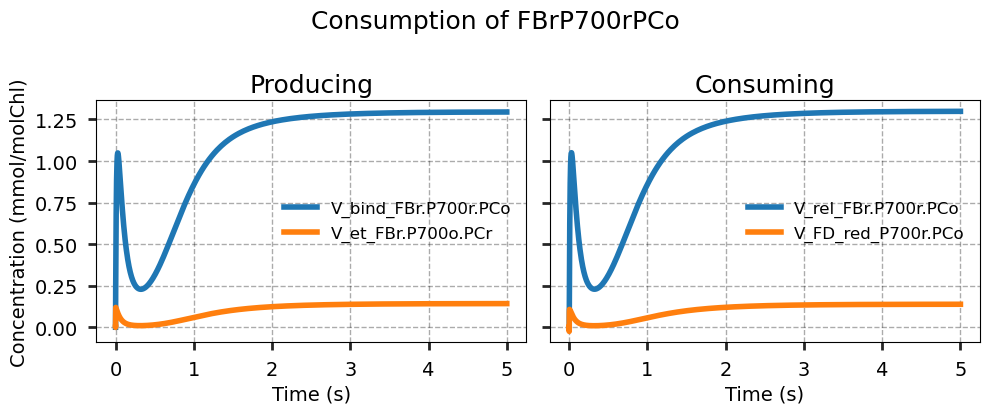

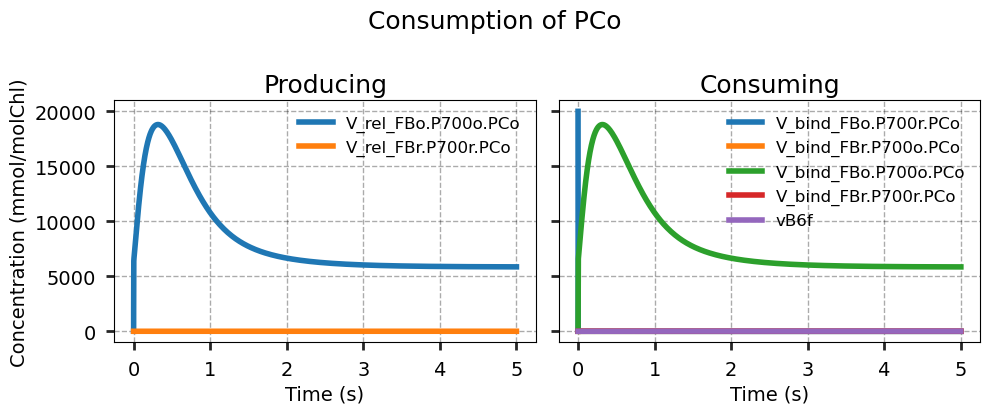

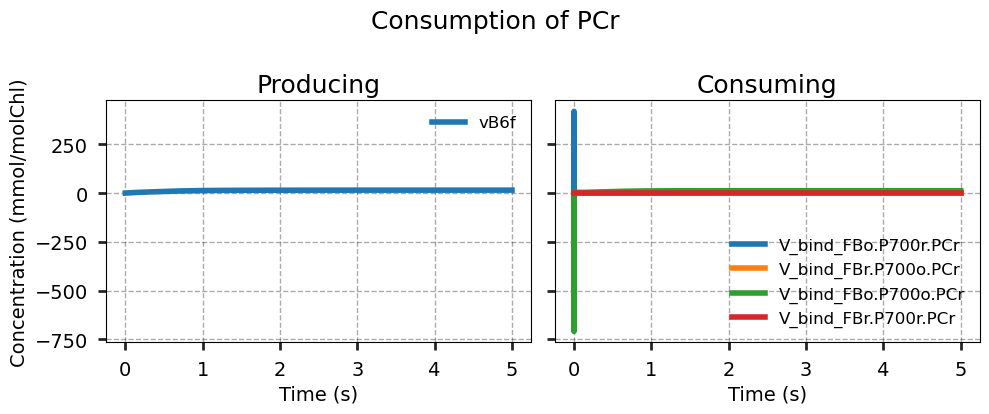

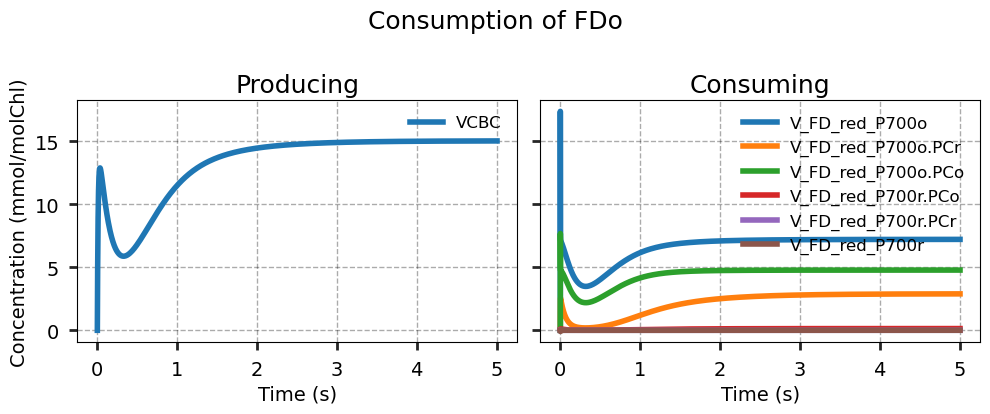

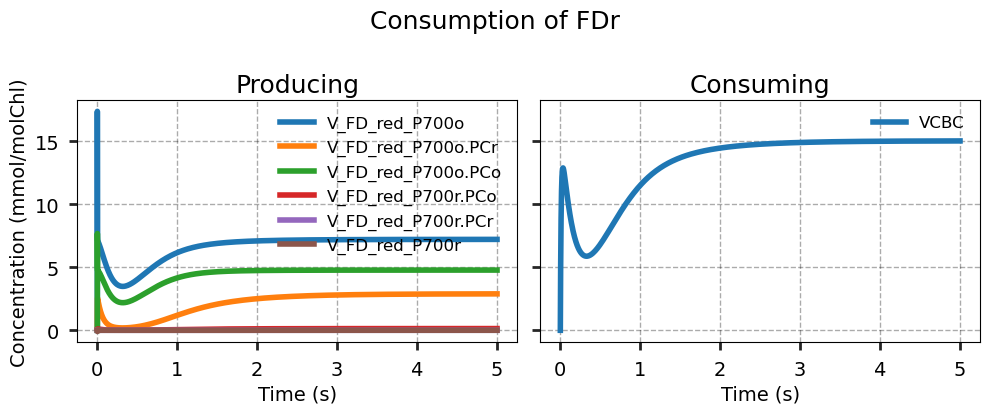

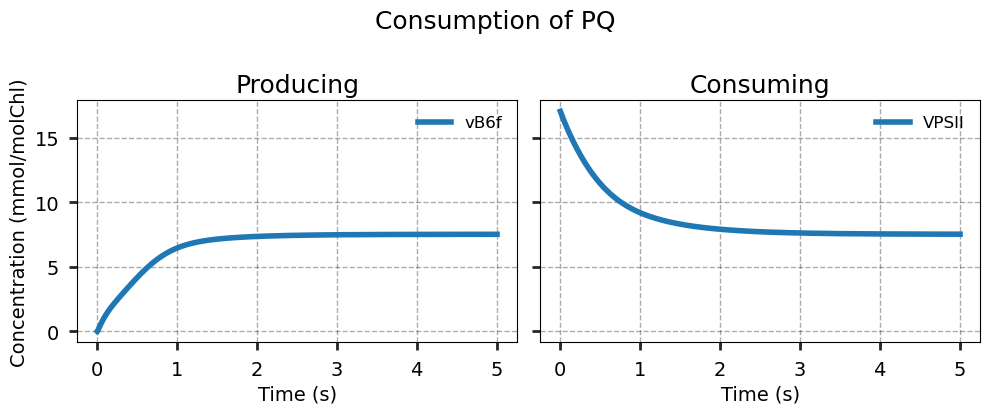

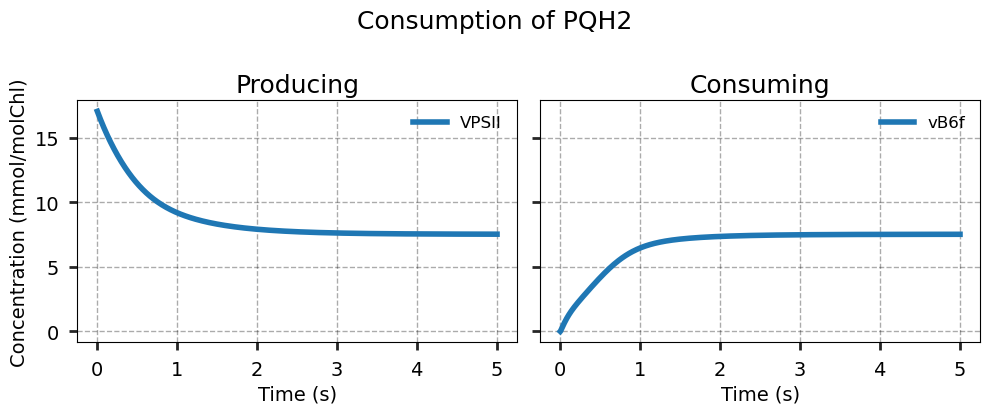

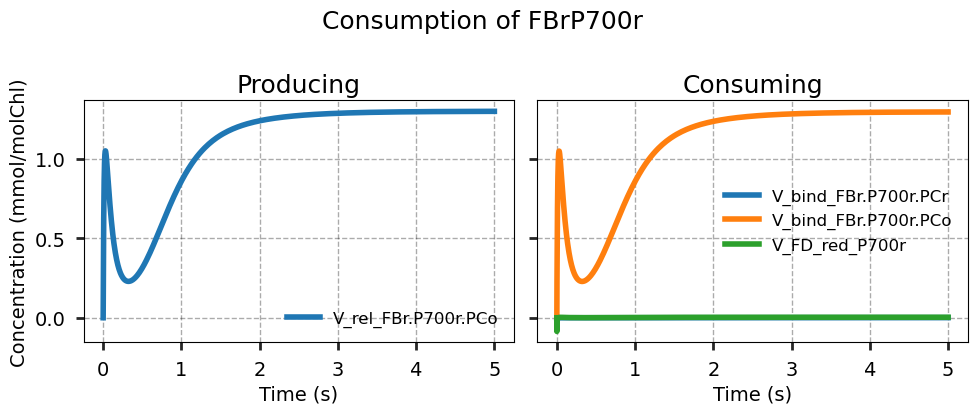

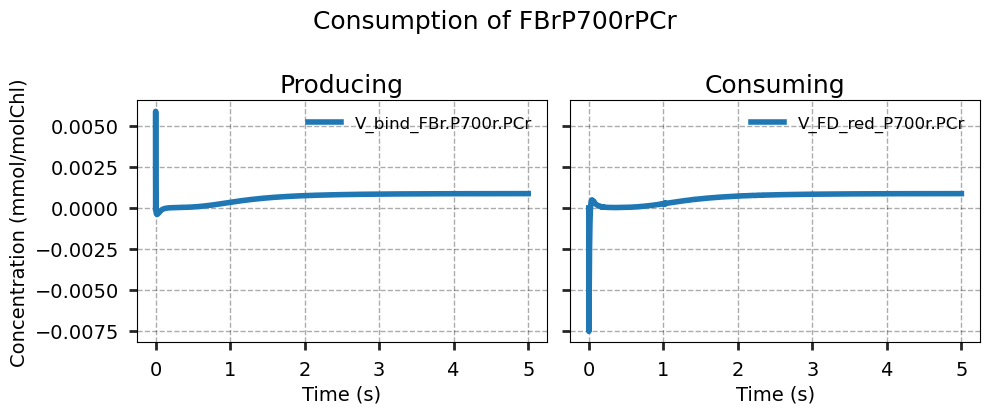

In [36]:
for key in y0.keys():
    if key!="P":
        result.plot_producing_and_consuming(key,xlabel="Time (s)",ylabel="Concentration (mmol/molChl)",title=f"Consumption of {key}")

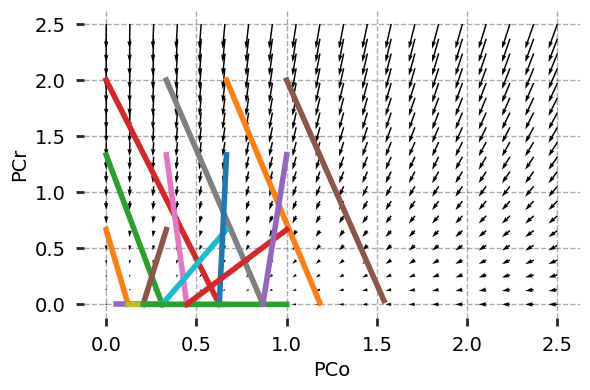

In [37]:
# phase plane analysis
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
s = Simulator(m).initialise(y0)

s.plot_trajectories(
    cpd1="PCo",
    cpd2="PCr",
    y0=y0,
    cpd1_bounds=(0, 2.5),
    cpd2_bounds=(0, 2.5),
    n=20,
    ax=ax,
)
for s1 in np.linspace(0, 1, 4):
    for s2 in np.linspace(0, 2, 4):
        (
        s.initialise({
        "FBoP700r": 2.5,  # mmol/molChl,FB.P70r concentration, e photosynthesis
        "FBoP700rPCr": 0.0,    # mmol/molChl,FB.P700.PCred concentration (PCred-bound state)
        "FBoP700rPCo": 0.0,    # mmol/molChl,FB.P700.PCox concentration (PCox-bound state)
        "FBrP700o": 0.0,    # mmol/molChl,FB-.P700+.PCox concentration (excited PCox-bound state)
        "FBrP700oPCr": 0.0,    # mmol/molChl,FB-.P700+ concentration (excited unbound state)
        "FBrP700oPCo": 0.0,    # mmol/molChl,FB-.P700+.PCred concentration (excited PCred-bound state)
        "FBoP700o": 0.0,    # mmol/molChl,FB-.P700.PCOx concentration (reduced unbound state)
        "FBoP700oPCr": 0.0,    # mmol/molChl,FFB.P700+.PCox concentration (oxidised P700 PCox-bound state)
        "FBoP700oPCo": 0.0,    # mmol/molChl,FB.P700+ concentration (oxidised P700)
        "FBrP700rPCo":0.0,    # mmol/molChl,FB.P700+.PCred concentration (oxidized PCred-bound state)
        "PCo": s1,#get_pool_size()['PC'],   # mmol/molChl, PCox concentration (oxidized plastocyanin), e photosynthesis
        "PCr": s2,#0*get_pool_size()['PC'],     # mmol/molChl, PCred concentration (reduced plastocyanin)
        "FDo": 5,     # mmol/molChl, Fd concentration (oxidised ferredoxin)
        "FDr": 0,    # mmol/molChl, Fd- concentration (reduced ferredoxin)
        "PQ": 17.5,    # mmol/molChl, PQ concentration (oxidised plastoquinon)
        "PQH2": 0.0,    # mmol/molChl, PQH2 concentration (reduced plastoquinon)
        "P": 0.0,     # mmol/molChl, product from Fd- consumption in CBC cycle
        "FBrP700r": 0.0,    # mmol/molChl, FBr.P700r concentration (excited PCox-bound state)
        "FBrP700rPCr": 0.0     # mmol/molChl, FBr.P700.PCr concentration (excited unbound state)

    })
            .simulate_and(t_end=5, steps=1)
            .plot_phase_plane("PCo", "PCr", ax=ax)
        )
fig.tight_layout()
plt.show()

In [38]:
# MCA
y0_mca= {
        "FBoP700r": 0.1*2.5,  # mmol/molChl,FB.P70r concentration, e photosynthesis
        "FBoP700rPCr": 0.1,    # mmol/molChl,FB.P700.PCred concentration (PCred-bound state)
        "FBoP700rPCo": 0.1,    # mmol/molChl,FB.P700.PCox concentration (PCox-bound state)
        "FBrP700o": 0.1,    # mmol/molChl,FB-.P700+.PCox concentration (excited PCox-bound state)
        "FBrP700oPCr": 0.1,    # mmol/molChl,FB-.P700+ concentration (excited unbound state)
        "FBrP700oPCo": 0.1,    # mmol/molChl,FB-.P700+.PCred concentration (excited PCred-bound state)
        "FBoP700o": 0.1,    # mmol/molChl,FB-.P700.PCOx concentration (reduced unbound state)
        "FBoP700oPCr": 0.1,    # mmol/molChl,FFB.P700+.PCox concentration (oxidised P700 PCox-bound state)
        "FBoP700oPCo": 0.1,    # mmol/molChl,FB.P700+ concentration (oxidised P700)
        "FBrP700rPCo":0.1,    # mmol/molChl,FB.P700+.PCred concentration (oxidized PCred-bound state)
        "PCo": 0.5*4,   # mmol/molChl, PCox concentration (oxidized plastocyanin), e photosynthesis
        "PCr": 0.5*4,     # mmol/molChl, PCred concentration (reduced plastocyanin)
        "FDo": 0.5*5,     # mmol/molChl, Fd concentration (oxidised ferredoxin)
        "FDr": 0.5*5,    # mmol/molChl, Fd- concentration (reduced ferredoxin)
        "PQ": 0.5*17.5,    # mmol/molChl, PQ concentration (oxidised plastoquinon)
        "PQH2": 0.5,    # mmol/molChl, PQH2 concentration (reduced plastoquinon)
        "P": 0.1,     # mmol/molChl, product from Fd- consumption in CBC cycle
        "FBrP700r": 0.1,    # mmol/molChl, FBr.P700r concentration (excited PCox-bound state)
        "FBrP700rPCr": 0.1,     # mmol/molChl, FBr.P700.PCr concentration (excited unbound state)

    }

crc = mca.get_compound_elasticities_df(
    m,
    compounds=list(y0.keys()),
    y = y0_mca
)

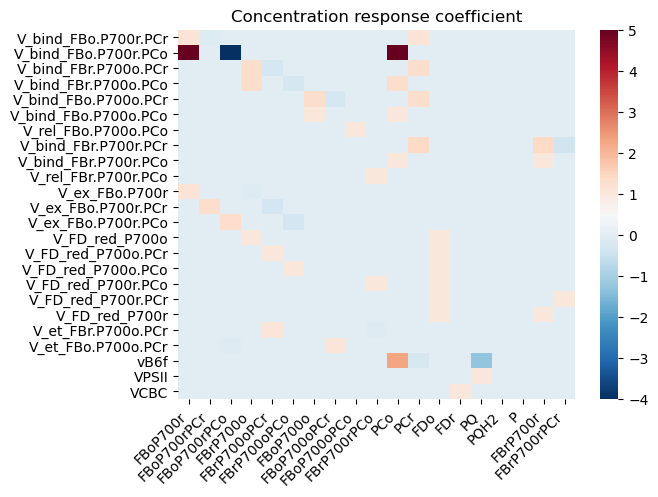

In [39]:
_ = mca.plot_coefficient_heatmap(
    crc,
    title="Concentration response coefficient",
    annotate=False,
)

In [40]:
# MCA
params = m.get_parameter_names()
frc = mca.get_parameter_elasticities_df(
    m,
    parameters=params,
    y = y0_mca,
)

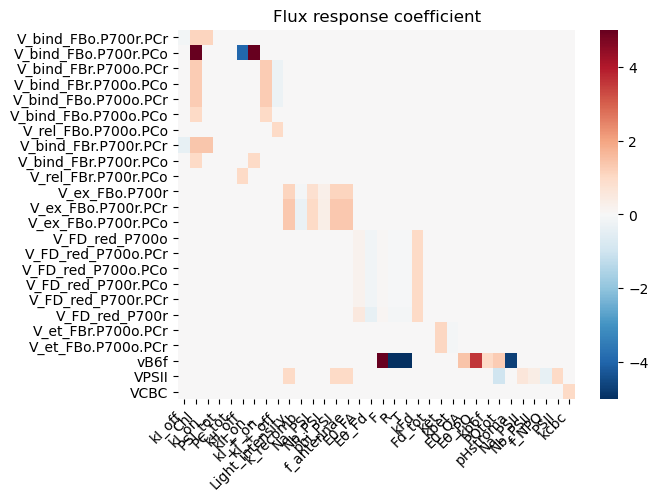

In [41]:
_ = mca.plot_coefficient_heatmap(
    frc,
    title="Flux response coefficient",
    annotate=False,
)

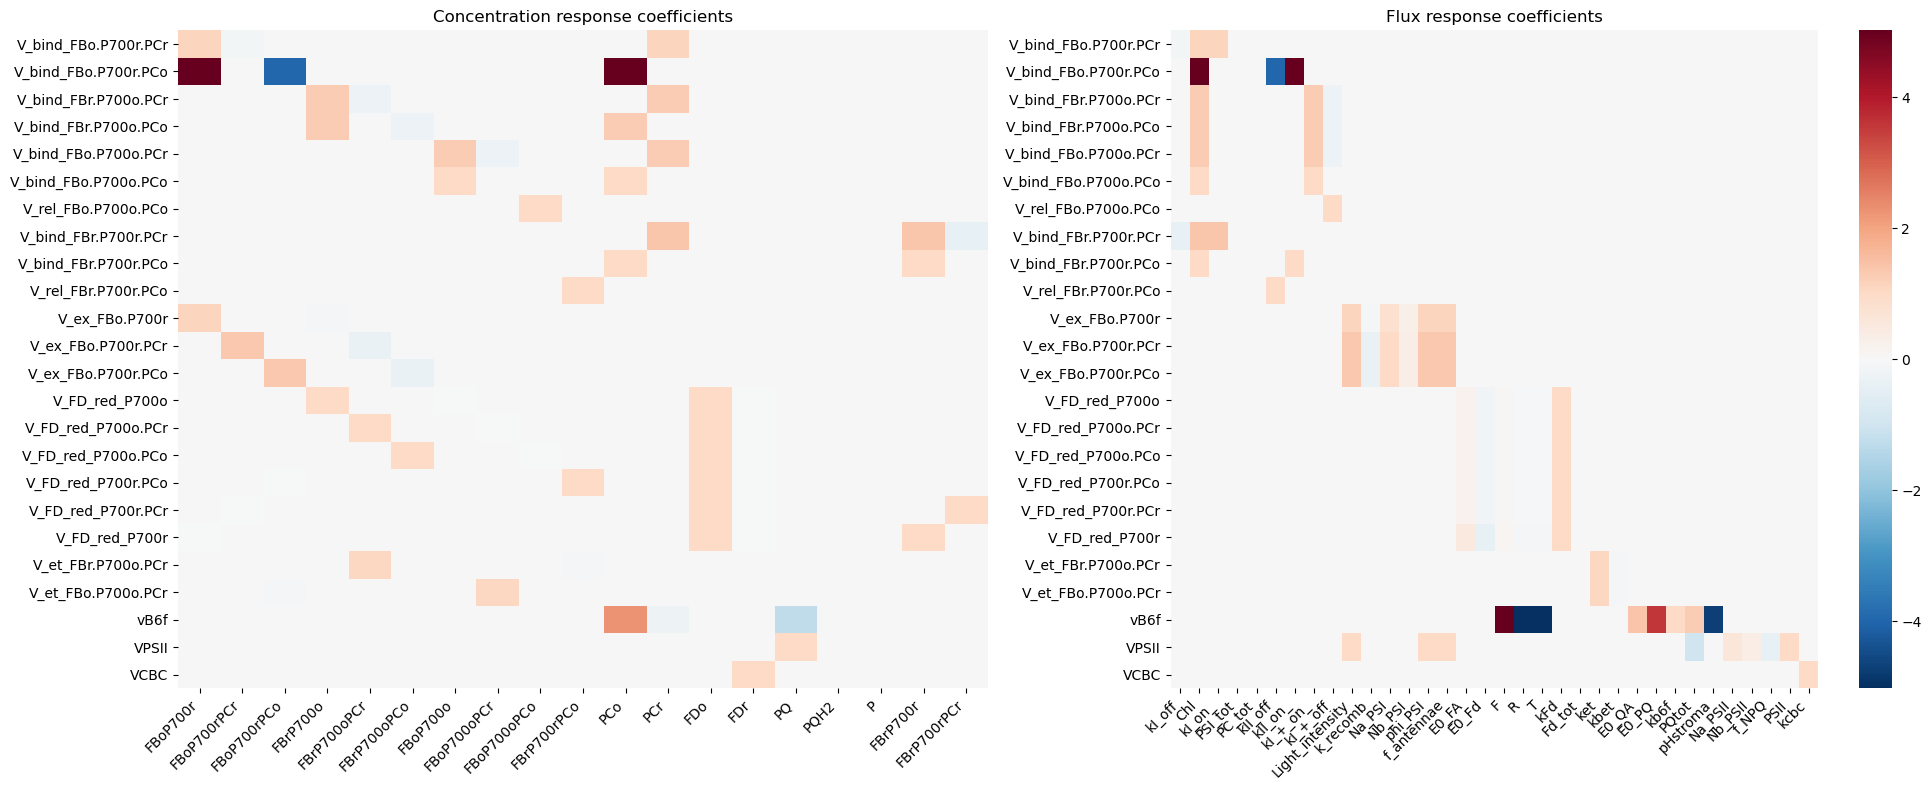

In [42]:
fig, axs = mca.plot_multiple(
    [crc, frc],
    titles=["Concentration response coefficients", "Flux response coefficients"],
    annotate=False,
    figsize=(20, 8),
)

In [43]:
from tqdm.notebook import tqdm
from modelbase.ode import Simulator
from typing import Iterable, Dict, Tuple, Optional, Any, List, Union
import itertools as it


def DIRK(s: Simulator,time_relax: float, relax_pfd: float,
         pfd_illumination: float, pre_dark_time:float, post_dark_time):
    t = it.accumulate([pre_dark_time,time_relax,post_dark_time])
    for time, pfd in tqdm(zip(t
                         ,[pfd_illumination,relax_pfd,pfd_illumination])):
        s.update_parameter("Light_intensity", pfd)
        print(pfd)
        print(time)
        s.simulate(time)

def PIRK(s: Simulator,time_relax: float, ss_pfd: float, time_pulse: float,
            pfd_dark:float, pfd_pulse: float, time_delay= bool):
    s.update_parameter("Light_intensity", ss_pfd)
    s.simulate(160)
    #s.update_parameter("pfd", pfd_dark)
    #s.simulate(160)
    pfds = list([pfd_pulse,pfd_dark]*4)
    if time_delay == True:
        t= list(it.accumulate(it.chain.from_iterable((time_pulse, time_relax*i) for i in [1,2,4,0.5])))
    if time_delay == False:
        t = list(it.accumulate(it.chain.from_iterable((time_pulse,time_relax) for i in range(4))))
    
    for i in range(len(t)):
        t[i] = t[i]+160
    #print(t)
    #print(pfds)
    for t,pfd in tqdm(zip(t,pfds)):
        s.update_parameter("Light_intensity", pfd)
        s.simulate(t)
        print(t,pfd)

In [44]:
s1 = Simulator(m)
s1.initialise(y0)
s1.clear_results()
DIRK(s1,time_relax=5, relax_pfd=0, pfd_illumination=300, 
     pre_dark_time=10, post_dark_time=10)

0it [00:00, ?it/s]

300
10
0
15
300
25


In [45]:
c = s1.get_full_results_df()
v = s1.get_fluxes_df()

In [46]:
c.columns

Index(['PCr', 'FBoP700r', 'FBoP700rPCr', 'PCo', 'FBoP700rPCo', 'FBrP700o',
       'FBrP700oPCr', 'FBrP700oPCo', 'FBoP700o', 'FBoP700oPCr', 'FBoP700oPCo',
       'FBrP700r', 'FBrP700rPCr', 'FBrP700rPCo', 'FDo', 'FDr', 'PQH2', 'PQ',
       'P'],
      dtype='object')

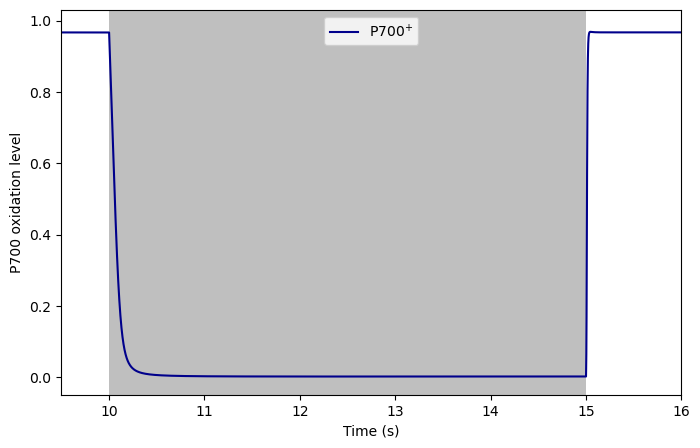

In [47]:

a0 = c["FBrP700o"]
a1 = c["FBrP700oPCr"]
a2 = c["FBrP700oPCo"]
a3 = c["FBoP700o"]
a4 = c["FBoP700oPCr"]
a5 = c["FBoP700oPCo"]

aT = m.get_parameter('PSI_tot')

p700_ox = a0+a1+a2+a3+a4+a5
fig,ax=plt.subplots(figsize=(8,5))

ax.plot(p700_ox/aT, label = "P700$^{+}$", color="darkblue")
# ax.plot(c["FDo"]/get_pool_size()['Fd'], label = "Fd", color="red")
# ax.plot(c["PCo"]/get_pool_size()['PC'], label = "PC", color="cyan")

ax.set(
    xlim=(9.5,16),
       xlabel=("Time (s)"),
       ylabel=("P700 oxidation level"))
       
ax.axvspan(10, 15, color='grey', alpha=0.5, lw=0)
ax.legend()

plt.show()


In [48]:
m.get_parameters()

{'kI_off': 3200.0,
 'Chl': 0.05,
 'kI_on_': 110000000.0,
 'PSI_tot': 2.5,
 'PC_tot': 4,
 'kII_off': 8000.0,
 'kII_on_': 40000000.0,
 'kI_+_on_': 600000000.0,
 'kI_+_off': 13000.0,
 'Light_intensity': 300,
 'k_recomb': 2.0,
 'Na_PSI': 254,
 'Nb_PSI': 85,
 'phi_PSI': 0.97,
 'f_antennae': 0.45,
 'E0_FA': -0.55,
 'E0_Fd': -0.43,
 'F': 96.485,
 'R': 0.0083,
 'T': 298.0,
 'kFd': 250000.0,
 'Fd_tot': 5,
 'ket': 58000.0,
 'kbet': 4500.0,
 'E0_QA': -0.14,
 'E0_PQ': 0.354,
 'kb6f': 2.5,
 'PQtot': 17.5,
 'pHstroma': 7.9,
 'Na_PSII': 261,
 'Nb_PSII': 158,
 'f_NPQ': 0.3,
 'PSII': 2.5,
 'kcbc': 100.0}

In [49]:
s1 = Simulator(m)
s1.initialise(y0)
s1.clear_results()
PIRK(s1,time_relax=0.05, ss_pfd=300, time_pulse=0.001, 
     pfd_dark=0, pfd_pulse=1180, time_delay=True)

0it [00:00, ?it/s]

160.001 1180
160.051 0
160.052 1180
160.152 0
160.153 1180
160.353 0
160.354 1180
160.379 0


In [50]:
c = s1.get_full_results_df()
v = s1.get_fluxes_df()

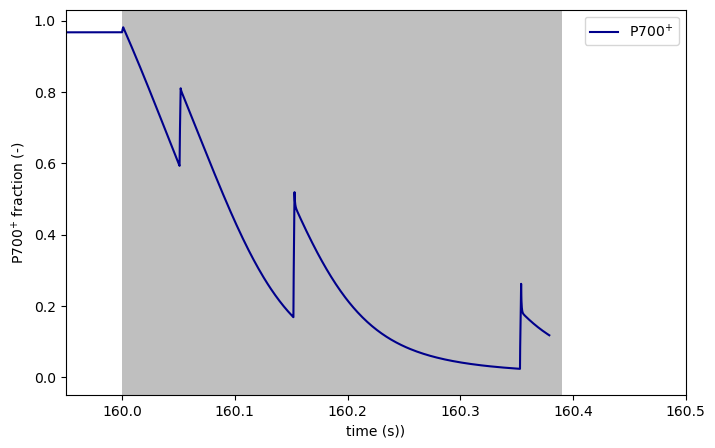

In [51]:

a0 = c["FBrP700o"]
a1 = c["FBrP700oPCr"]
a2 = c["FBrP700oPCo"]
a3 = c["FBoP700o"]
a4 = c["FBoP700oPCr"]
a5 = c["FBoP700oPCo"]

aT = m.get_parameter('PSI_tot')

p700_ox = a0+a1+a2+a3+a4+a5
fig,ax=plt.subplots(figsize=(8,5))

ax.plot(p700_ox/aT, label = "P700$^{+}$", color="darkblue")
# ax.plot(c["FDo"]/get_pool_size()['Fd'], label = "Fd", color="red")
# ax.plot(c["PCo"]/get_pool_size()['PC'], label = "PC", color="cyan")

ax.set(
    xlim=(159.95,160.5),
       #ylim=(0.16,0.5),
       xlabel=("time (s))"),
       ylabel=(r"P700$^{+}$ fraction (-)"))
ax.axvspan(160, 160.39, color='grey', alpha=0.5, lw=0)
ax.legend(loc='upper right')  # slightly outside the plot


plt.show()


In [52]:
print(m.generate_model_source_code())

import math
import numpy as np
from modelbase.ode import Model, Simulator


def mass_action_1(S1: float, k_fwd: float) -> float:
    return k_fwd * S1


def mass_action_2(S1: float, S2: float, k_fwd: float) -> float:
    return k_fwd * S1 * S2


def reversible_mass_action_1_1(
    S1: float,
    P1: float,
    k_fwd: float,
    k_bwd: float,
) -> float:
    return k_fwd * S1 - k_bwd * P1


def reversible_mass_action_2_1(
    S1: float,
    S2: float,
    P1: float,
    k_fwd: float,
    k_bwd: float,
) -> float:
    return k_fwd * S1 * S2 - k_bwd * P1


def reversible_mass_action_2_2(
    S1: float,
    S2: float,
    P1: float,
    P2: float,
    k_fwd: float,
    k_bwd: float,
) -> float:
    return k_fwd * S1 * S2 - k_bwd * P1 * P2


def vB6f(PCo, PCr, PQ, PQtot, k_b6f, Keq_b6f):
    k_b6f_reverse = k_b6f / Keq_b6f
    f_PQ = (
        PQ / PQtot
    )  # want to keep the rates in terms of fraction of PQHs, not total number
    f_PQH2 = 1 - f_PQ
    return f_PQH2 * PCo**2 * k_b6f - 